In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
np.random.seed(42)

n = 1200
x_base = np.random.uniform(-10 , 20 , n)

beta0_true = 5.0
beta1_true = 2.5
y_true_base = beta0_true + beta1_true * x_base

noise_sd = 3.0
y_base = y_true_base + np.random.normal(0 , noise_sd , n)

In [3]:
k = 45
x_out = np.random.uniform(11 , 20 , k)
y_out = beta0_true + beta1_true * x_out + np.random.normal(55 , 20 , k)

x = np.concatenate([x_base , x_out])
y = np.concatenate([y_base , y_out])

is_outlier = np.zeros_like(x , dtype = bool)
is_outlier[-k : ] = True
is_inlier = ~ is_outlier

In [4]:
X = sm.add_constant(x)

ols = sm.OLS(y , X).fit()
lad = sm.QuantReg(y , X).fit(q = 0.5)

xg = np.linspace(x.min() , x.max() , 400)
Xg = sm.add_constant(xg)

y_true_line = beta0_true + beta1_true * xg
y_ols_line = ols.predict(Xg)
y_lad_line = lad.predict(Xg)

yhat_ols = ols.predict(X)
yhat_lad = lad.predict(X)

res_ols = y - yhat_ols
res_lad = y - yhat_lad

In [5]:
def rmse(a , b):
    return np.sqrt(np.mean((a - b) ** 2))

def binned_mae(x_vals , residuals , bins = 18):
    edges = np.linspace(x_vals.min() , x_vals.max() , bins + 1)
    mids = 0.5 * (edges[ : -1] + edges[1 : ])
    vals = np.full(bins , np.nan)

    for i in range(bins):
        m = (x_vals >= edges[i]) & (x_vals < edges[i + 1])
        if np.sum(m) >= 10:
            vals[i] = np.mean(np.abs(residuals[m]))
    return mids , vals

In [6]:
rmse_inlier_ols = rmse(y[is_inlier] , yhat_ols[is_inlier])
rmse_inlier_lad = rmse(y[is_inlier] , yhat_lad[is_inlier])

mae_inlier_ols = np.mean(np.abs(y[is_inlier] - yhat_ols[is_inlier]))
mae_inlier_lad = np.mean(np.abs(y[is_inlier] - yhat_lad[is_inlier]))

x_in = x[is_inlier]
mae_curve_ols_x , mae_curve_ols = binned_mae(x_in , res_ols[is_inlier] , bins = 18)
_ , mae_curve_lad = binned_mae(x_in , res_lad[is_inlier] , bins = 18)

<Figure size 1050x600 with 0 Axes>

Text(0.5, 1.0, 'OLS vs LAD: Outliers Pull OLS More Than LAD')

Text(0.5, 0, 'X')

Text(0, 0.5, 'y')

Text(0.02, 0.98, 'True slope: 2.50\nOLS slope: 2.74\nLAD slope: 2.51')

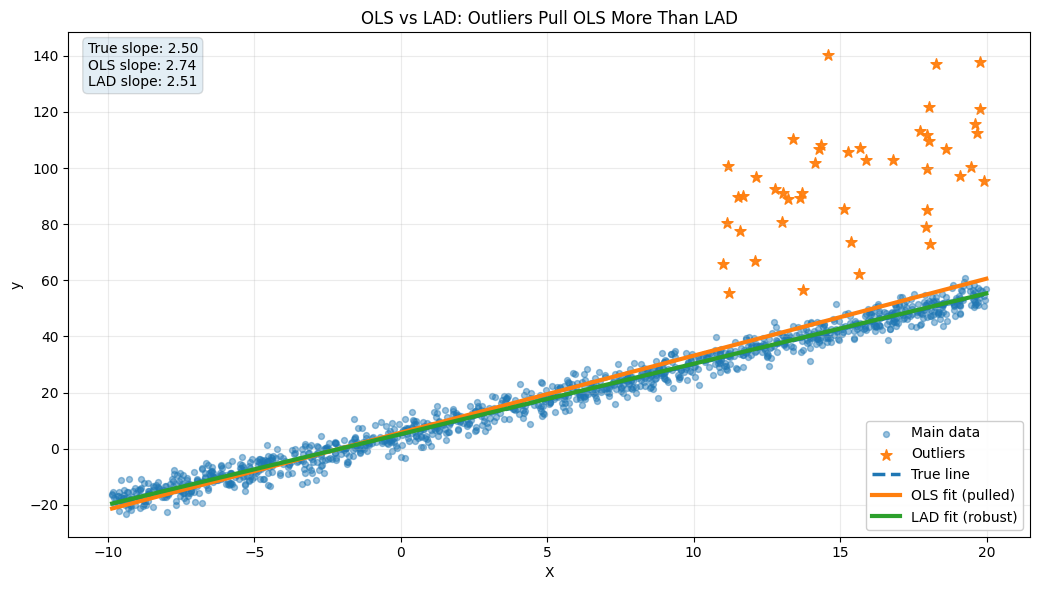

In [7]:
plt.figure(figsize = (10.5 , 6))

plt.scatter(x[is_inlier] , y[is_inlier] , s = 18 , alpha = 0.45 , label = "Main data")
plt.scatter(x[is_outlier] , y[is_outlier] , s = 70 , marker = "*" , alpha = 0.95 , label = "Outliers")
plt.plot(xg , y_true_line , linestyle = "--" , linewidth = 2.5 , label = "True line")
plt.plot(xg , y_ols_line , linewidth = 3 , label = "OLS fit (pulled)")
plt.plot(xg , y_lad_line , linewidth = 3 , label = "LAD fit (robust)")

plt.title("OLS vs LAD: Outliers Pull OLS More Than LAD")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(alpha = 0.25)

summary = (
    f"True slope: {beta1_true:.2f}\n"
    f"OLS slope: {ols.params[1]:.2f}\n"
    f"LAD slope: {lad.params[1]:.2f}"
)
plt.text(
    0.02 , 0.98 , summary , transform = plt.gca().transAxes ,
    va = "top" , bbox = dict(boxstyle = "round , pad = 0.35" , alpha = 0.12)
)
plt.legend(loc = "lower right" , framealpha = 0.95)
plt.tight_layout()
plt.show()

<Figure size 1050x600 with 0 Axes>

Text(0.5, 1.0, 'Main-Data Error Across X: LAD Protects the Core Fit')

Text(0.5, 0, 'X')

Text(0, 0.5, 'Mean absolute residual (main data only)')

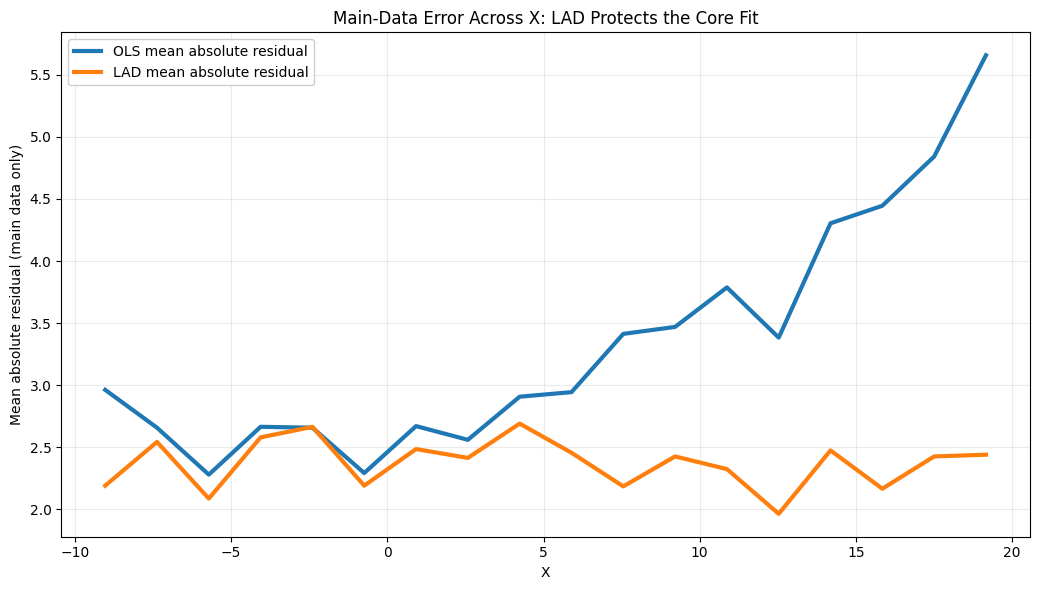

In [8]:
plt.figure(figsize = (10.5 , 6))

plt.plot(mae_curve_ols_x , mae_curve_ols , linewidth = 3 , label = "OLS mean absolute residual")
plt.plot(mae_curve_ols_x , mae_curve_lad , linewidth = 3 , label = "LAD mean absolute residual")

plt.title("Main-Data Error Across X: LAD Protects the Core Fit")
plt.xlabel("X")
plt.ylabel("Mean absolute residual (main data only)")
plt.grid(alpha = 0.25)
plt.legend(loc = "upper left" , framealpha = 0.95)
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

<BarContainer object of 2 artists>

<BarContainer object of 2 artists>

([<matplotlib.axis.XTick at 0x7ee0815c3080>,
 [Text(0, 0, 'OLS'), Text(1, 0, 'LAD')])

Text(0, 0.5, 'Error')

Text(0.5, 1.0, 'Main-Data Error Comparison: OLS vs LAD')

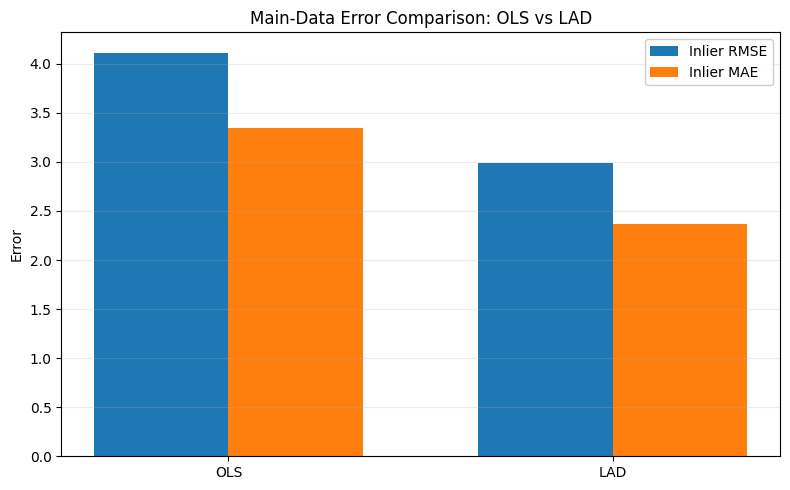

In [9]:
labels = ["OLS" , "LAD"]
rmse_vals = [rmse_inlier_ols , rmse_inlier_lad]
mae_vals = [mae_inlier_ols , mae_inlier_lad]
xpos = np.arange(len(labels))
width = 0.35

plt.figure(figsize = (8 , 5))
plt.bar(xpos - width / 2 , rmse_vals , width = width , label = "Inlier RMSE")
plt.bar(xpos + width / 2 , mae_vals , width = width , label = "Inlier MAE")

plt.xticks(xpos , labels)
plt.ylabel("Error")
plt.title("Main-Data Error Comparison: OLS vs LAD")
plt.grid(axis = "y" , alpha = 0.25)
plt.legend(framealpha = 0.95)
plt.tight_layout()
plt.show()

In [10]:
print("============ Model Comparison ============")
print(f"True slope = {beta1_true:.3f} , intercept = {beta0_true:.3f}")
print(f"OLS  slope = {ols.params[1]:.3f} , intercept = {ols.params[0]:.3f}")
print(f"LAD  slope = {lad.params[1]:.3f} , intercept = {lad.params[0]:.3f}")
print()
print(f"Inlier RMSE: OLS = {rmse_inlier_ols:.3f} , LAD = {rmse_inlier_lad:.3f}")
print(f"Inlier MAE : OLS = {mae_inlier_ols:.3f} , LAD = {mae_inlier_lad:.3f}")

============ Model Comparison ============
True slope = 2.500 , intercept = 5.000
OLS  slope = 2.743 , intercept = 5.743
LAD  slope = 2.508 , intercept = 5.216

Inlier RMSE: OLS = 4.115 , LAD = 2.993
Inlier MAE : OLS = 3.343 , LAD = 2.372
